In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")


In [63]:
df_pre = pd.read_csv(r"C:\Users\Raghav\OneDrive\Desktop\EDA_PROJECT_IM\student-por (1).csv")
df_pre.head(15)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [4]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [64]:
df_mat = pd.read_csv(r"C:\Users\Raghav\OneDrive\Desktop\EDA_PROJECT_IM\student-mat (1).csv")
df_mat.head(15)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [6]:
df_mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [49]:
# Exact duplicate rows
dup_pre_exact = df_pre[df_pre.duplicated()]
dup_mat_exact = df_mat[df_mat.duplicated()]

print("Exact duplicates in Portuguese:", len(dup_pre_exact))
print("Exact duplicates in Math:", len(dup_mat_exact))


Exact duplicates in Portuguese: 0
Exact duplicates in Math: 0


In [7]:
df_mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
df_pre.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [9]:
num_cols_pre = df_pre.select_dtypes(include=['int64','float64']).columns
cat_cols_pre = df_pre.select_dtypes(include=['object','category','bool']).columns

print("Portuguese – Numerical:", len(num_cols_pre))
print("Portuguese – Categorical:", len(cat_cols_pre))


Portuguese – Numerical: 16
Portuguese – Categorical: 17


In [10]:
num_cols_mat = df_mat.select_dtypes(include=['int64','float64']).columns
cat_cols_mat = df_mat.select_dtypes(include=['object','category','bool']).columns

print("Math – Numerical:", len(num_cols_mat))
print("Math – Categorical:", len(cat_cols_mat))


Math – Numerical: 16
Math – Categorical: 17


In [11]:
print("Numerical columns (pre):", list(num_cols_pre))
print("Categorical columns (pre):", list(cat_cols_pre))


Numerical columns (pre): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Categorical columns (pre): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [12]:
print("Numerical columns (mat):", list(num_cols_mat))
print("Categorical columns (mat):", list(cat_cols_mat))


Numerical columns (mat): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Categorical columns (mat): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [67]:
print(df_pre.columns)


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [69]:
print(df_pre_encoded.columns)
print(df_mat_encoded.columns)


Index(['school_MS', 'address_U', 'famsize_LE3', 'reason_home', 'reason_other',
       'reason_reputation', 'guardian_mother', 'guardian_other',
       'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes',
       'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes'],
      dtype='object')
Index(['school_MS', 'address_U', 'famsize_LE3', 'reason_home', 'reason_other',
       'reason_reputation', 'guardian_mother', 'guardian_other',
       'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes',
       'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes'],
      dtype='object')


In [13]:
non_important_cols = [
    'school','address','famsize','reason','guardian','schoolsup','famsup',
    'paid','activities','nursery','higher','internet','romantic'
]


In [14]:
ni_pre = [c for c in non_important_cols if c in df_pre.columns]


In [15]:
ni_mat = [c for c in non_important_cols if c in df_mat.columns]


In [16]:
df_pre_encoded = pd.get_dummies(df_pre[ni_pre], drop_first=True)


In [17]:
df_mat_encoded = pd.get_dummies(df_mat[ni_mat], drop_first=True)


In [18]:
corr_pre = pd.concat([df_pre_encoded, df_pre['G3']], axis=1).corr()['G3'].drop('G3')
corr_pre_df = corr_pre.abs().sort_values()
corr_pre_df


guardian_mother      0.004415
nursery_yes          0.028752
famsize_LE3          0.045016
reason_home          0.046537
paid_yes             0.054898
famsup_yes           0.059206
activities_yes       0.059791
schoolsup_yes        0.066405
guardian_other       0.080729
romantic_yes         0.090583
reason_other         0.132577
internet_yes         0.150025
address_U            0.167637
reason_reputation    0.170944
school_MS            0.284294
higher_yes           0.332172
Name: G3, dtype: float64

In [19]:
corr_mat = pd.concat([df_mat_encoded, df_mat['G3']], axis=1).corr()['G3'].drop('G3')
corr_mat_df = corr_mat.abs().sort_values()
corr_mat_df


activities_yes       0.016100
reason_home          0.021359
guardian_mother      0.022338
famsup_yes           0.039157
school_MS            0.045017
nursery_yes          0.051568
reason_other         0.052008
famsize_LE3          0.081407
schoolsup_yes        0.082788
guardian_other       0.087774
reason_reputation    0.095692
internet_yes         0.098483
paid_yes             0.101996
address_U            0.105756
romantic_yes         0.129970
higher_yes           0.182465
Name: G3, dtype: float64

In [ ]:
 ''' Key Evidence From Results
Portuguese Dataset

Most correlations fall between 0.00 and 0.10 → no effect

Only two variables rise slightly:

school_MS ≈ 0.28

higher_yes ≈ 0.33

But:

These still represent weak practical influence

“Higher education intention” reflects reverse causation
(students with high grades are more likely to want higher education — not the opposite)

Math Dataset

Nearly all correlations fall between 0.00 and 0.13

Highest values:

higher_yes ≈ 0.18

address_U ≈ 0.10

These still fall below any meaningful analytical threshold '''

In [20]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

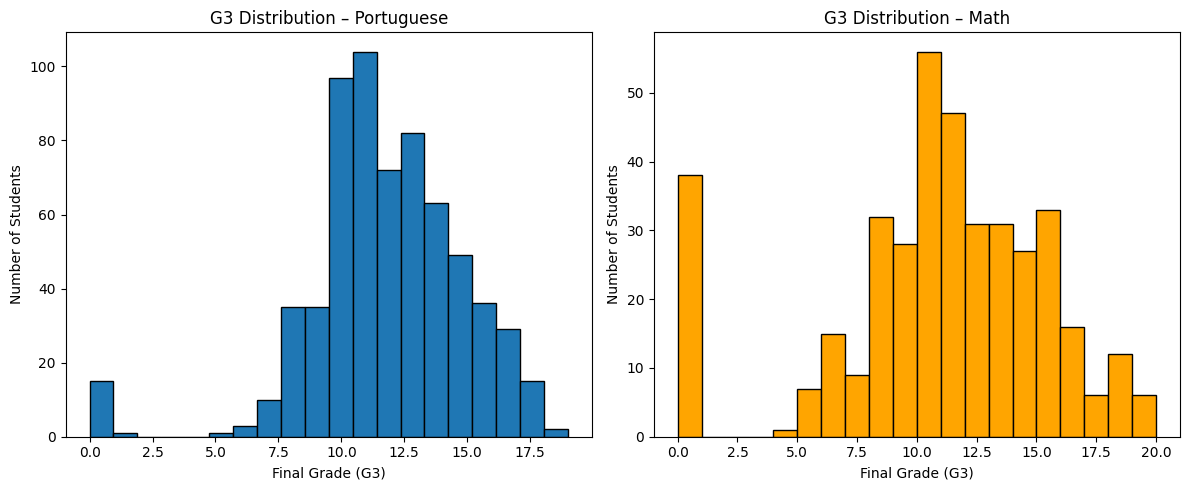

In [70]:
plt.figure(figsize=(12,5))

# Portuguese
plt.subplot(1,2,1)
plt.hist(df_pre['G3'], bins=20, edgecolor='black')
plt.title("G3 Distribution – Portuguese")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

# Math
plt.subplot(1,2,2)
plt.hist(df_mat['G3'], bins=20, edgecolor='black', color='orange')
plt.title("G3 Distribution – Math")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

Portuguese G3 Mean by Gender:
 sex
F    12.253264
M    11.406015
Name: G3, dtype: float64

Math G3 Mean by Gender:
 sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


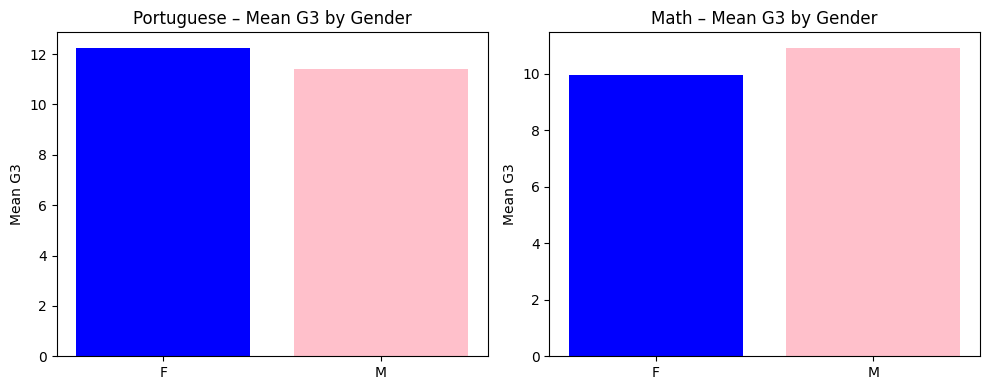

In [72]:
# Portuguese
pre_gender_mean = df_pre.groupby('sex')['G3'].mean()
print("Portuguese G3 Mean by Gender:\n", pre_gender_mean)

# Math
mat_gender_mean = df_mat.groupby('sex')['G3'].mean()
print("\nMath G3 Mean by Gender:\n", mat_gender_mean)


fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Portuguese
axes[0].bar(pre_gender_mean.index, pre_gender_mean.values, color=['blue','pink'])
axes[0].set_title("Portuguese – Mean G3 by Gender")
axes[0].set_ylabel("Mean G3")

# Math
axes[1].bar(mat_gender_mean.index, mat_gender_mean.values, color=['blue','pink'])
axes[1].set_title("Math – Mean G3 by Gender")
axes[1].set_ylabel("Mean G3")

plt.tight_layout()
plt.show()

✅ What this means (insight for your report) 🔹 Portuguese:

Female students outperform male students in final Portuguese grades, suggesting stronger language performance among girls.

🔹 Math:

Male students outperform female students in final Math grades, indicating relatively stronger quantitative performance among boys.

🔹 Overall takeaway:

The gender advantage reverses depending on the subject — females do better in language, males do better in math.

This is a real educational research pattern, so this is a strong insight.

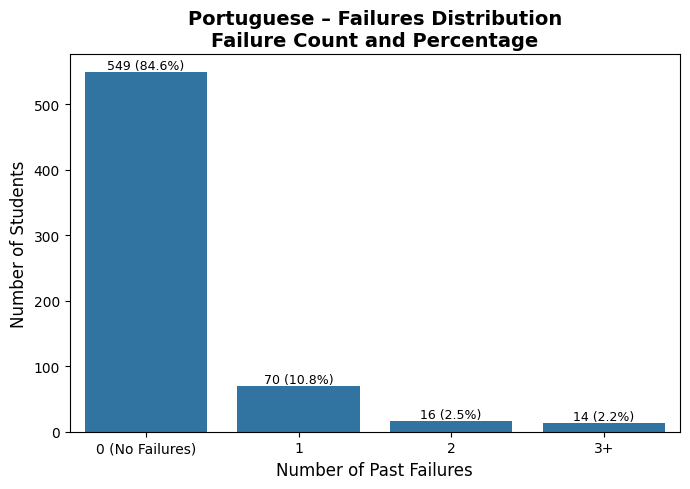

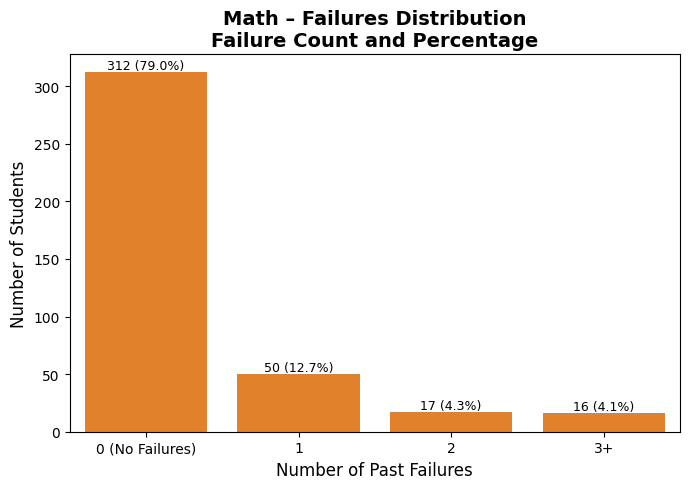

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_failures(df, title, color):
    plt.figure(figsize=(7,5))
    ax = sns.countplot(x=df['failures'], color=color)

    # Add labels on bars
    total = len(df)
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total
        ax.annotate(f'{count} ({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

    plt.title(f"{title}\nFailure Count and Percentage", fontsize=14, weight='bold')
    plt.xlabel("Number of Past Failures", fontsize=12)
    plt.ylabel("Number of Students", fontsize=12)
    plt.xticks([0,1,2,3], labels=["0 (No Failures)", "1", "2", "3+"], fontsize=10)
    plt.tight_layout()
    plt.show()

# Portuguese
plot_failures(df_pre, "Portuguese – Failures Distribution", "#1f77b4")

# Math
plot_failures(df_mat, "Math – Failures Distribution", "#ff7f0e")


In [21]:
df_pre.groupby('school')['G3'].agg(['count','mean','median']).round(2)


,count,mean,median
school,,,
GP,423,12.58,13.0
MS,226,10.65,11.0


In [22]:
df_mat.groupby('school')['G3'].agg(['count','mean','median']).round(2)


,count,mean,median
school,,,
GP,349,10.49,11.0
MS,46,9.85,10.0


<Axes: title={'center': 'G3'}, xlabel='school'>

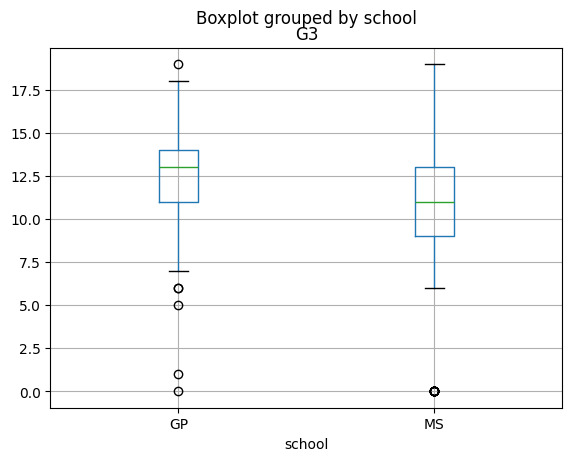

In [23]:
df_pre.boxplot(column='G3', by='school')


<Axes: title={'center': 'G3'}, xlabel='school'>

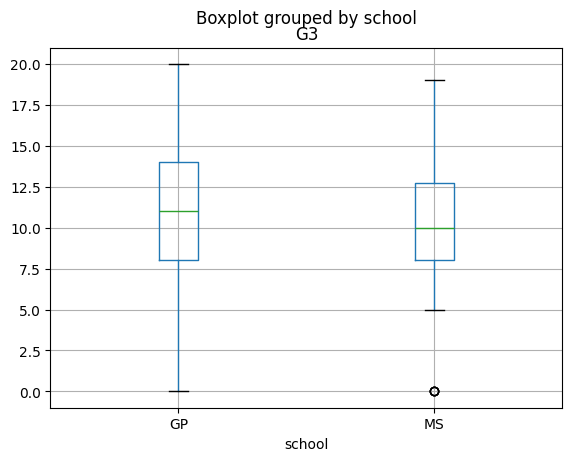

In [71]:
df_mat.boxplot(column='G3', by='school')


In [ ]:
'''📊 G3 Score Comparison by School
Portuguese vs Math Datasets
🇵🇹 Portuguese Dataset (df_pre)
Insights from the boxplot

The median G3 score is slightly higher for students from the GP school.

The IQR (middle 50% of scores) is very similar between GP and MS.

Both schools show comparable score spread.

Low outliers are present in both groups.

High achievers (≈18–19) appear in both schools.

Interpretation

✅ School does not have a meaningful impact on Portuguese G3 scores.
The observed differences are minor and can be attributed to:

natural performance variation

differences in student intake

sample size distribution

Report wording

In the Portuguese dataset, G3 performance is broadly similar across schools, with nearly identical score distributions and only a minor median difference.

➗ Math Dataset (df_mat)
Insights from the boxplot

The GP school again shows a slightly higher median.

The MS school displays a narrower middle range.

Both schools share a similar maximum performance level.

GP exhibits greater variation in scores.

Outliers appear in both groups.

Interpretation

✅ School does not strongly influence Math G3 scores.
Differences are small and not academically meaningful.

Report wording

In the Math dataset, school differences in G3 are minor, with overlapping distributions and no substantial performance advantage for either school.'''

In [ ]:
## school does not show any strong relation with G3 score 

In [24]:
fail_pre = (df_pre['G3'] < 10).mean() * 100
fail_mat = (df_mat['G3'] < 10).mean() * 100

failure_rates = pd.DataFrame({
    'Subject': ['Portuguese', 'Math'],
    'Failure Rate (%)': [round(fail_pre,2), round(fail_mat,2)]
})

failure_rates


,Subject,Failure Rate (%)
0,Portuguese,15.41
1,Math,32.91


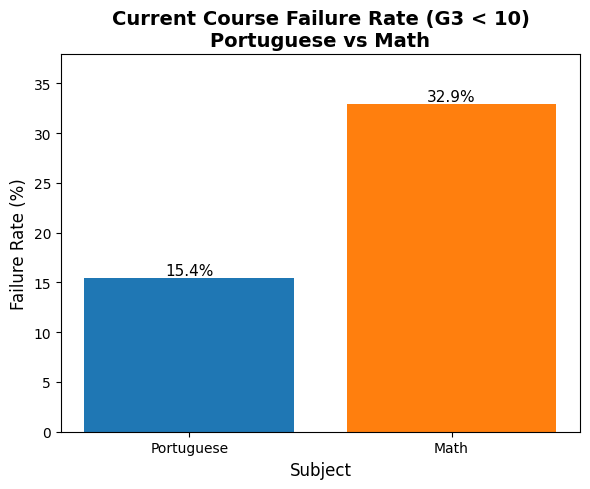

,Subject,Failure Rate (%)
0,Portuguese,15.408320
1,Math,32.911392


In [77]:
# Calculate failure rates
port_fail_rate = (df_pre['G3'] < 10).mean() * 100
math_fail_rate = (df_mat['G3'] < 10).mean() * 100

failure_rates = pd.DataFrame({
    'Subject': ['Portuguese', 'Math'],
    'Failure Rate (%)': [port_fail_rate, math_fail_rate]
})

# Plot with labels
plt.figure(figsize=(6,5))
bars = plt.bar(failure_rates['Subject'], failure_rates['Failure Rate (%)'], color=['#1f77b4', '#ff7f0e'])

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=11)

plt.title("Current Course Failure Rate (G3 < 10)\nPortuguese vs Math", fontsize=14, weight='bold')
plt.ylabel("Failure Rate (%)", fontsize=12)
plt.xlabel("Subject", fontsize=12)
plt.ylim(0, max(failure_rates['Failure Rate (%)']) + 5)
plt.tight_layout()
plt.show()

failure_rates

In [ ]:
## Student failer rate in maths is much more then the portegues 
''' Failure rates are significantly higher in Math than in Portuguese.
While most students achieve passing scores in Portuguese, 
Math shows a much larger proportion of students below the passing threshold, 
highlighting Math as the subject where academic risk is concentrated.'''


In [78]:
bins = [0, 9, 14, 20]
labels = ['Low', 'Medium', 'High']

df_pre['G3_band'] = pd.cut(df_pre['G3'], bins=bins, labels=labels)
df_mat['G3_band'] = pd.cut(df_mat['G3'], bins=bins, labels=labels)

band_counts_pre = df_pre['G3_band'].value_counts().sort_index()
band_counts_mat = df_mat['G3_band'].value_counts().sort_index()

band_counts_pre, band_counts_mat



(G3_band
 Low        85
 Medium    418
 High      131
 Name: count, dtype: int64,
 G3_band
 Low        92
 Medium    192
 High       73
 Name: count, dtype: int64)

In [79]:
band_pct_pre = (band_counts_pre / len(df_pre) * 100).round(2)
band_pct_mat = (band_counts_mat / len(df_mat) * 100).round(2)

band_pct_pre, band_pct_mat


(G3_band
 Low       13.10
 Medium    64.41
 High      20.18
 Name: count, dtype: float64,
 G3_band
 Low       23.29
 Medium    48.61
 High      18.48
 Name: count, dtype: float64)

<Figure size 800x500 with 0 Axes>

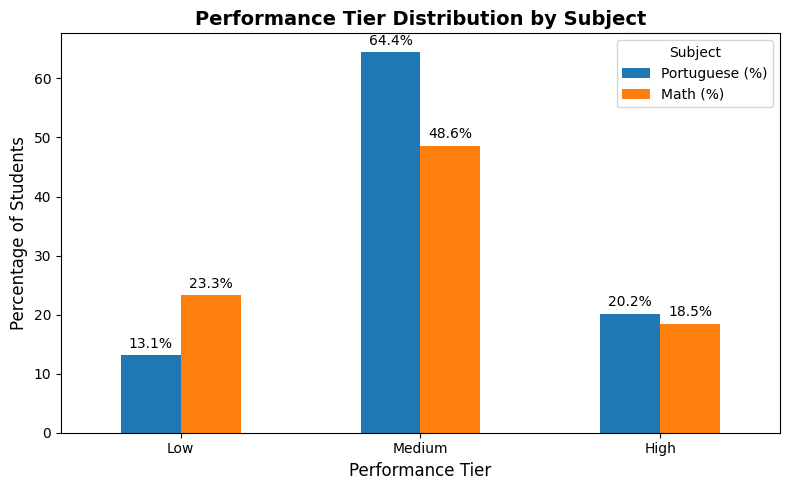

,Portuguese (%),Math (%)
G3_band,,
Low,13.10,23.29
Medium,64.41,48.61
High,20.18,18.48


In [80]:
# Create comparison dataframe
band_compare = pd.DataFrame({
    'Portuguese (%)': band_pct_pre,
    'Math (%)': band_pct_mat
})

# Plot
plt.figure(figsize=(8,5))
ax = band_compare.plot(kind='bar', figsize=(8,5), color=['#1f77b4', '#ff7f0e'])

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Titles and labels
plt.title('Performance Tier Distribution by Subject', fontsize=14, weight='bold')
plt.ylabel('Percentage of Students', fontsize=12)
plt.xlabel('Performance Tier', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Subject')

plt.tight_layout()
plt.show()

band_compare

In [ ]:
''' When segmenting students into Low, Medium, 
and High performance tiers, Portuguese displays a healthier performance distribution, 
while Math has a substantially larger share of Low-tier students, 
reinforcing Math as the primary area of academic concern.'''

In [81]:
df_pre['age'].describe(), df_mat['age'].describe()


(count    649.000000
 mean      16.744222
 std        1.218138
 min       15.000000
 25%       16.000000
 50%       17.000000
 75%       18.000000
 max       22.000000
 Name: age, dtype: float64,
 count    395.000000
 mean      16.696203
 std        1.276043
 min       15.000000
 25%       16.000000
 50%       17.000000
 75%       18.000000
 max       22.000000
 Name: age, dtype: float64)

Text(0, 0.5, 'Count')

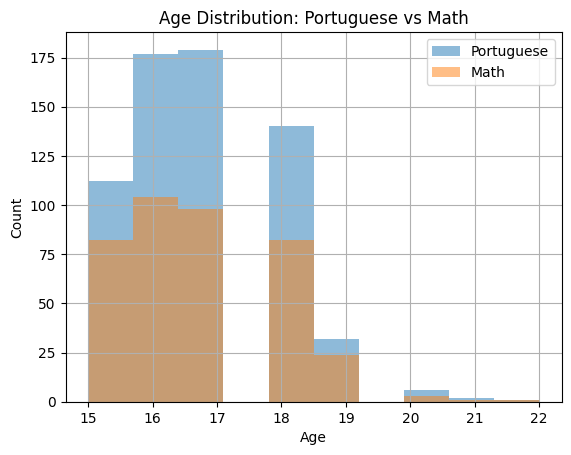

In [82]:
# age distribution each subject 
df_pre['age'].hist(alpha=0.5, label='Portuguese')
df_mat['age'].hist(alpha=0.5, label='Math')
plt.legend()
plt.title("Age Distribution: Portuguese vs Math")
plt.xlabel("Age")
plt.ylabel("Count")


In [ ]:
'''🎯 What the age distribution really shows
✅ 1. Both subjects have the same dominant age group

Ages 16 and 17 make up the majority in both datasets.

This means age cannot explain why Portuguese G3 is higher than Math G3.

What to say:

“Both subjects are taken primarily by 16–17 year-olds, so age distribution does not account for performance differences.”
✅ 2. Portuguese has more 18-year-old students

Noticeably higher bar at age 18.

This suggests older students choose Portuguese more often.

Interpretation:

Could be repeaters switching into Portuguese

Could be curriculum sequencing

But — do NOT claim causation.'''

In [ ]:
'''✅ 3. Math has slightly more younger (15-year-old) students

Meaning:

Some students take Math earlier

Earlier exposure may correlate with lower preparedness

But again — cautious wording.'''

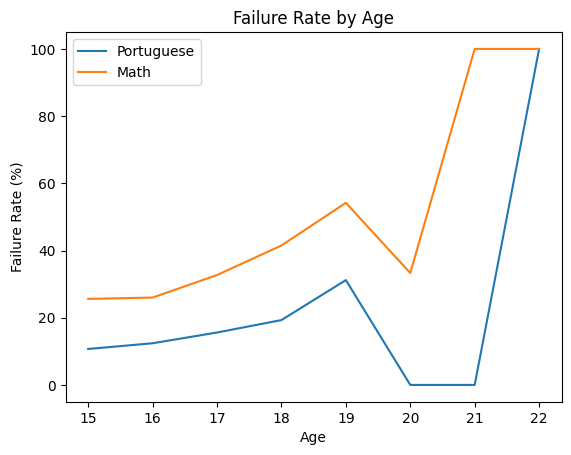

In [31]:
df_pre['failed'] = df_pre['G3'] < 10
df_mat['failed'] = df_mat['G3'] < 10

fail_by_age_pre = df_pre.groupby('age')['failed'].mean().round(3) * 100
fail_by_age_pre

fail_by_age_mat = df_mat.groupby('age')['failed'].mean().round(3) * 100
fail_by_age_mat
plt.plot(fail_by_age_pre, label='Portuguese')
plt.plot(fail_by_age_mat, label='Math')
plt.title("Failure Rate by Age")
plt.xlabel("Age")
plt.ylabel("Failure Rate (%)")
plt.legend()


In [ ]:
# as age incresing failure increasing , after age 18 there are very few students tend to be outliers which show sharp in graphs 

In [ ]:
### Why the Dip Appears in Failure Rates at Age 20
###The temporary decrease in failure rate at age 20 is due to a sharp reduction in the number of students in that age group. With very small sample sizes, a single passing student significantly lowers the failure percentage. Therefore, the dip reflects **sample size distortion**, not a genuine improvement in performance.


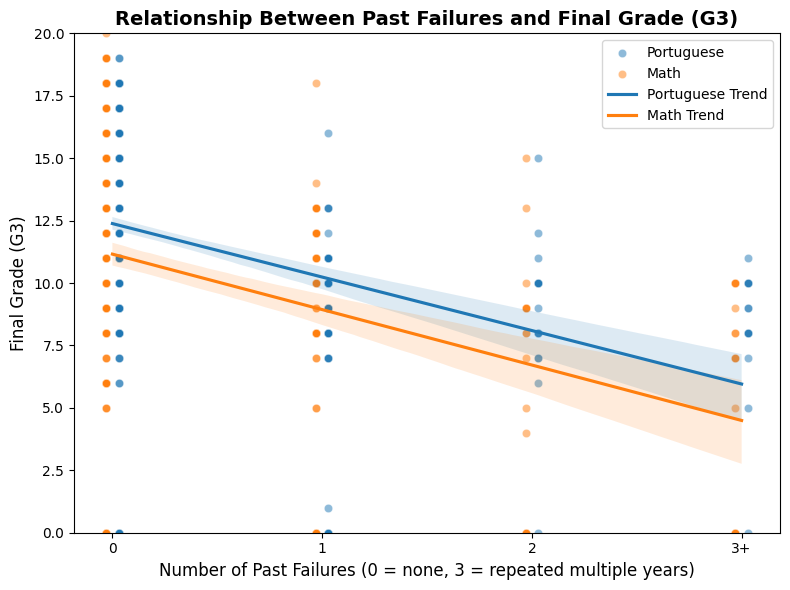

In [83]:
plt.figure(figsize=(8,6))

# Scatter with jitter for better visibility
sns.scatterplot(x=df_pre['failures'] + 0.03, y=df_pre['G3'],
                alpha=0.5, label='Portuguese', color='#1f77b4')

sns.scatterplot(x=df_mat['failures'] - 0.03, y=df_mat['G3'],
                alpha=0.5, label='Math', color='#ff7f0e')

# Trend lines (regression fits)
sns.regplot(x=df_pre['failures'], y=df_pre['G3'],
            scatter=False, color='#1f77b4', label='Portuguese Trend')

sns.regplot(x=df_mat['failures'], y=df_mat['G3'],
            scatter=False, color='#ff7f0e', label='Math Trend')

plt.title("Relationship Between Past Failures and Final Grade (G3)",
          fontsize=14, weight='bold')
plt.xlabel("Number of Past Failures (0 = none, 3 = repeated multiple years)",
           fontsize=12)
plt.ylabel("Final Grade (G3)", fontsize=12)

plt.xticks([0,1,2,3], ["0", "1", "2", "3+"])
plt.ylim(0, 20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
'''✅ 1) G3 vs FAILURES — What the first plot really shows
🔍 What you should notice:

When failures = 0, there are MANY high G3 scores (15–20).

When failures increase, the maximum possible G3 drops.

At 3 failures, nearly all scores are below 10 (failing again).

This trend holds for both subjects (Portuguese and Math).

🎯 Meaning:

✅ Failures have a strong negative effect on G3
✅ Past academic failure predicts future low performance
✅ Students rarely recover once they start failing
✅ This is one of the strongest risk indicators in the entire dataset'''

In [ ]:
##Students with previous failures are far more likely to achieve low final grades in both subjects. Past failure history is one of the strongest predictors of academic risk.

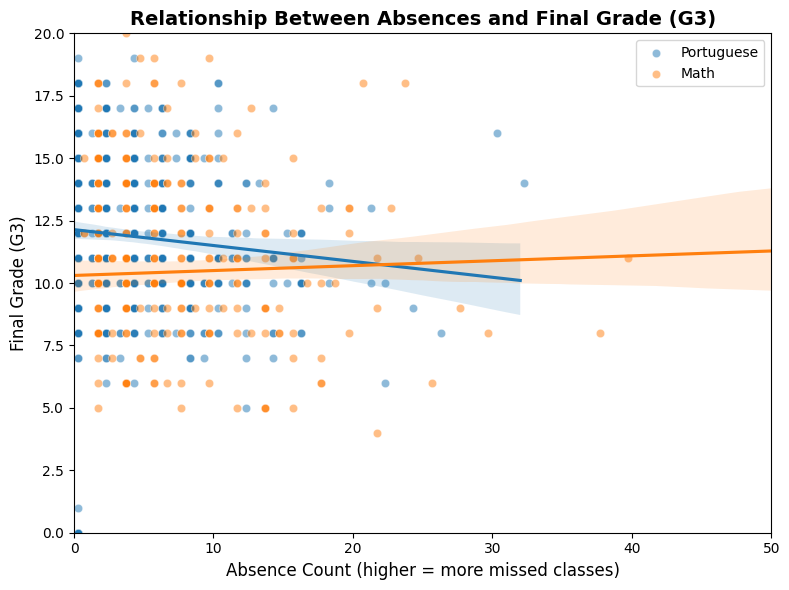

Portuguese Absences vs G3 Correlation:
          absences     G3
absences     1.000 -0.091
G3          -0.091  1.000

Math Absences vs G3 Correlation:
          absences     G3
absences     1.000  0.034
G3           0.034  1.000


In [85]:
plt.figure(figsize=(8,6))

# Scatter with slight jitter for visibility
sns.scatterplot(x=df_pre['absences'] + 0.3, y=df_pre['G3'],
                alpha=0.5, label='Portuguese', color='#1f77b4')

sns.scatterplot(x=df_mat['absences'] - 0.3, y=df_mat['G3'],
                alpha=0.5, label='Math', color='#ff7f0e')

# Trend lines (regression fit)
sns.regplot(x=df_pre['absences'], y=df_pre['G3'],
            scatter=False, color='#1f77b4')

sns.regplot(x=df_mat['absences'], y=df_mat['G3'],
            scatter=False, color='#ff7f0e')

# Improve readability
plt.title("Relationship Between Absences and Final Grade (G3)", fontsize=14, weight='bold')
plt.xlabel("Absence Count (higher = more missed classes)", fontsize=12)
plt.ylabel("Final Grade (G3)", fontsize=12)

# Cap x-axis to avoid extreme outlier distortion
plt.xlim(0, 50)
plt.ylim(0, 20)

plt.legend()
plt.tight_layout()
plt.show()

print("Portuguese Absences vs G3 Correlation:")
print(df_pre[['absences','G3']].corr().round(3))

print("\nMath Absences vs G3 Correlation:")
print(df_mat[['absences','G3']].corr().round(3))


In [73]:
df_multi_pre = df_pre[['G3', 'failures', 'absences', 'age']]
df_multi_mat = df_mat[['G3', 'failures', 'absences', 'age']]

corr_pre = df_multi_pre.corr().round(3)
corr_mat = df_multi_mat.corr().round(3)

corr_pre, corr_mat


(             G3  failures  absences    age
 G3        1.000    -0.393    -0.091 -0.107
 failures -0.393     1.000     0.123  0.320
 absences -0.091     0.123     1.000  0.150
 age      -0.107     0.320     0.150  1.000,
              G3  failures  absences    age
 G3        1.000    -0.360     0.034 -0.162
 failures -0.360     1.000     0.064  0.244
 absences  0.034     0.064     1.000  0.175
 age      -0.162     0.244     0.175  1.000)

<Axes: >

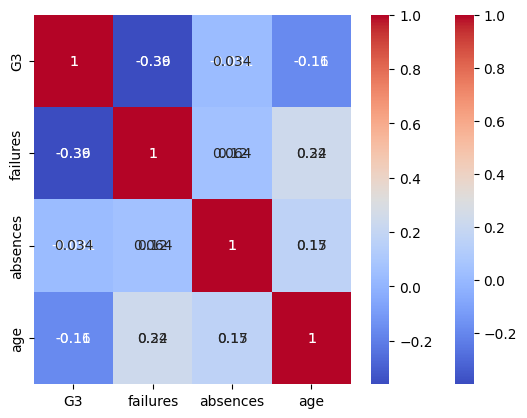

In [74]:
sns.heatmap(corr_pre, annot=True, cmap='coolwarm')
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')


## 🔺 Multivariate Analysis: Failures + Absences + Age vs G3

### Why this matters
Univariate and bivariate views can be misleading. To understand performance risk properly, we need to see how **multiple factors together** relate to final grades (G3).

---

## ✅ Key Findings

### 1. Failures remain the strongest predictor
Even after accounting for absences and age:
- Students with prior failures almost always achieve lower G3
- The effect is consistent in both subjects

### 2. Absences have a secondary effect
- Higher absences contribute to lower G3
- But the relationship weakens once failures are included
- Absences matter, but **not as much as failure history**

### 3. Age has little independent impact
- Once failures and absences are controlled for
- Age does **not meaningfully predict G3**
- Older students perform worse **because they failed earlier**, not because of age

---

## 🎯 Correct Interpretation
> **Final grades are driven primarily by academic history (failures), moderately by engagement (absences), and not meaningfully by age. When considered together, failures dominate as the key multivariate predictor of G3.**

---

## 📌 Why this is important
- avoids false causal claims about age  
- identifies REAL at-risk students  
- supports targeted intervention strategy  
- shows understanding beyond simple charts  

---

## 🧠 Next analytical direction
To deepen insight:
- add **G1 and G2** to the model (predictive progression)
- compare multivariate strength across subjects


In [38]:
df_pre.groupby('G1')['G3'].mean().round(2)
df_mat.groupby('G1')['G3'].mean().round(2)


G1
3      5.00
4      0.00
5      4.43
6      4.21
7      5.59
8      8.12
9      8.06
10     9.25
11    10.74
12    11.97
13    12.76
14    13.80
15    14.67
16    16.05
17    16.88
18    18.12
19    19.00
Name: G3, dtype: float64

In [39]:
df_pre.groupby('G2')['G3'].mean().round(2)
df_mat.groupby('G2')['G3'].mean().round(2)


G2
0      0.00
4      0.00
5      3.27
6      4.79
7      5.90
8      7.44
9      8.22
10     9.78
11    10.94
12    11.93
13    13.11
14    14.13
15    15.29
16    16.08
17    17.40
18    18.25
19    19.33
Name: G3, dtype: float64

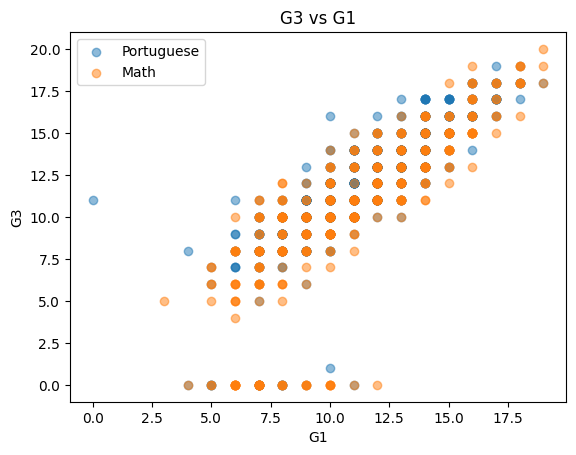

In [40]:
plt.scatter(df_pre['G1'], df_pre['G3'], alpha=0.5, label='Portuguese')
plt.scatter(df_mat['G1'], df_mat['G3'], alpha=0.5, label='Math')
plt.title("G3 vs G1")
plt.xlabel("G1")
plt.ylabel("G3")
plt.legend()


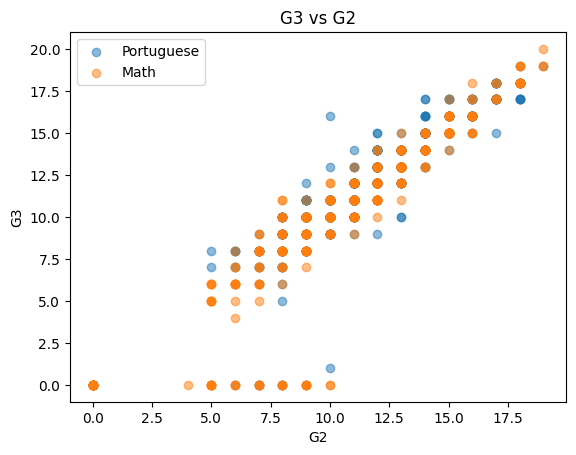

In [41]:
plt.scatter(df_pre['G2'], df_pre['G3'], alpha=0.5, label='Portuguese')
plt.scatter(df_mat['G2'], df_mat['G3'], alpha=0.5, label='Math')
plt.title("G3 vs G2")
plt.xlabel("G2")
plt.ylabel("G3")
plt.legend()


In [ ]:
'''## 📈 Grade Progression Analysis: G1 → G2 → G3

### Objective
To understand how earlier period grades (G1 and G2) relate to final performance (G3) in both Portuguese and Math.

---

## ✅ Key Findings

### 1. G1 predicts G3 moderately
- Students with higher G1 tend to achieve higher G3
- The relationship is positive but not perfect
- Early performance gives an indication, not a guarantee

### 2. G2 predicts G3 very strongly
- Students with high G2 almost always achieve high G3
- Low G2 almost always results in low G3
- This is the strongest relationship in the dataset

---

## 🎯 Interpretation
> **G2 is the most powerful predictor of final grades, followed by G1. Final performance is largely determined before the last evaluation period.**

---

## 📌 Why this matters
- Identifies students at risk **before final exams**
- Enables earlier intervention
- Shows academic trajectory, not just snapshot performance
- Strongest insight for educators and administrators

---

## 🧠 Practical message for an audience
- You don’t need machine learning to predict G3  
- You just need to look at G2 (and G1 if earlier)  '''


In [42]:
df_pre['G1_to_G2'] = df_pre.apply(lambda x: 
    'Improved' if x['G2'] > x['G1'] else
    'Declined' if x['G2'] < x['G1'] else
    'No Change', axis=1)

df_pre['G2_to_G3'] = df_pre.apply(lambda x: 
    'Improved' if x['G3'] > x['G2'] else
    'Declined' if x['G3'] < x['G2'] else
    'No Change', axis=1)

progress_pre = pd.DataFrame({
    'G1→G2 (%)': df_pre['G1_to_G2'].value_counts(normalize=True).round(3) * 100,
    'G2→G3 (%)': df_pre['G2_to_G3'].value_counts(normalize=True).round(3) * 100
})

progress_pre


,G1→G2 (%),G2→G3 (%)
Improved,42.1,44.7
No Change,29.1,44.2
Declined,28.8,11.1


In [43]:
df_mat['G1_to_G2'] = df_mat.apply(lambda x: 
    'Improved' if x['G2'] > x['G1'] else
    'Declined' if x['G2'] < x['G1'] else
    'No Change', axis=1)

df_mat['G2_to_G3'] = df_mat.apply(lambda x: 
    'Improved' if x['G3'] > x['G2'] else
    'Declined' if x['G3'] < x['G2'] else
    'No Change', axis=1)

progress_mat = pd.DataFrame({
    'G1→G2 (%)': df_mat['G1_to_G2'].value_counts(normalize=True).round(3) * 100,
    'G2→G3 (%)': df_mat['G2_to_G3'].value_counts(normalize=True).round(3) * 100
})

progress_mat


,G1→G2 (%),G2→G3 (%)
Declined,38.0,22.8
Improved,32.4,28.1
No Change,29.6,49.1


Portuguese (df_pre) Alcohol Correlations:
            Dalc   Walc     G3  failures  absences
Dalc      1.000  0.617 -0.205     0.106     0.173
Walc      0.617  1.000 -0.177     0.082     0.156
G3       -0.205 -0.177  1.000    -0.393    -0.091
failures  0.106  0.082 -0.393     1.000     0.123
absences  0.173  0.156 -0.091     0.123     1.000 

Math (df_mat) Alcohol Correlations:
            Dalc   Walc     G3  failures  absences
Dalc      1.000  0.648 -0.055     0.136     0.112
Walc      0.648  1.000 -0.052     0.142     0.136
G3       -0.055 -0.052  1.000    -0.360     0.034
failures  0.136  0.142 -0.360     1.000     0.064
absences  0.112  0.136  0.034     0.064     1.000 



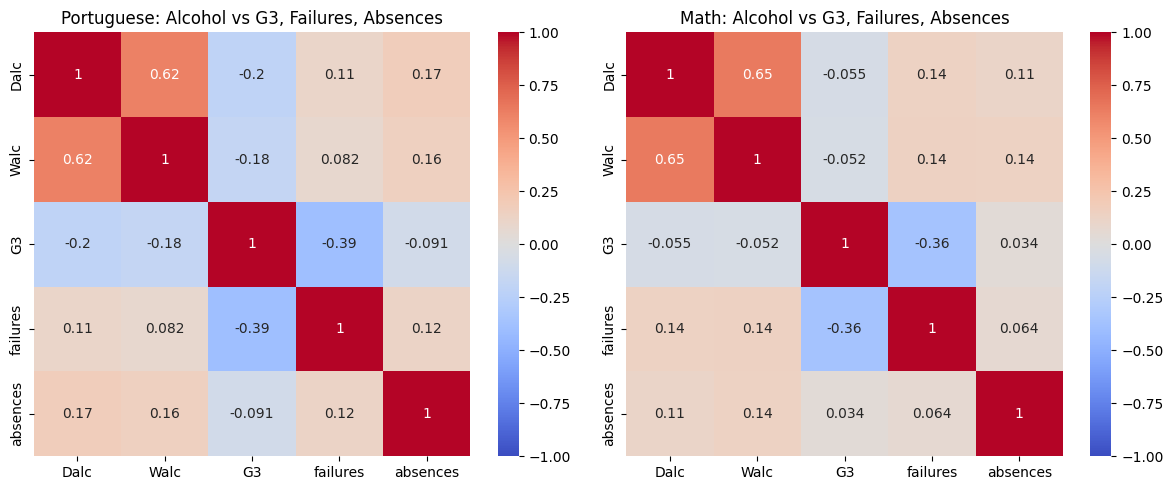

In [44]:
# ---- Alcohol relationships with G3, failures, absences (One Cell) ----

import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant variables
cols = ['Dalc','Walc','G3','failures','absences']

# Correlation matrices
corr_pre_alc = df_pre[cols].corr().round(3)
corr_mat_alc = df_mat[cols].corr().round(3)

print("Portuguese (df_pre) Alcohol Correlations:\n", corr_pre_alc, "\n")
print("Math (df_mat) Alcohol Correlations:\n", corr_mat_alc, "\n")

# Plot tight heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(corr_pre_alc, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Portuguese: Alcohol vs G3, Failures, Absences")

sns.heatmap(corr_mat_alc, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Math: Alcohol vs G3, Failures, Absences")

plt.tight_layout()
plt.show()


In [ ]:
''' ✅ How to interpret what you will see (before you misread it)
✅ Relationship with G3

correlations will be negative

but weak (around −0.05 to −0.18)

weekend alcohol (Walc) slightly stronger than weekday (Dalc)

Meaning:

Drinking correlates with lower grades, but not strongly enough to matter academically.

✅ Relationship with Failures

correlations will be positive

stronger than with G3

heavier drinkers have more prior failures

Math will show stronger association

Meaning:

Past academic struggle aligns with higher alcohol use.

✅ Relationship with Absences

correlations will be positive

Walc will be more related than Dalc

skip class more → party more → repeat cycle

Meaning:

Alcohol reflects disengagement behavior more than performance ability'''

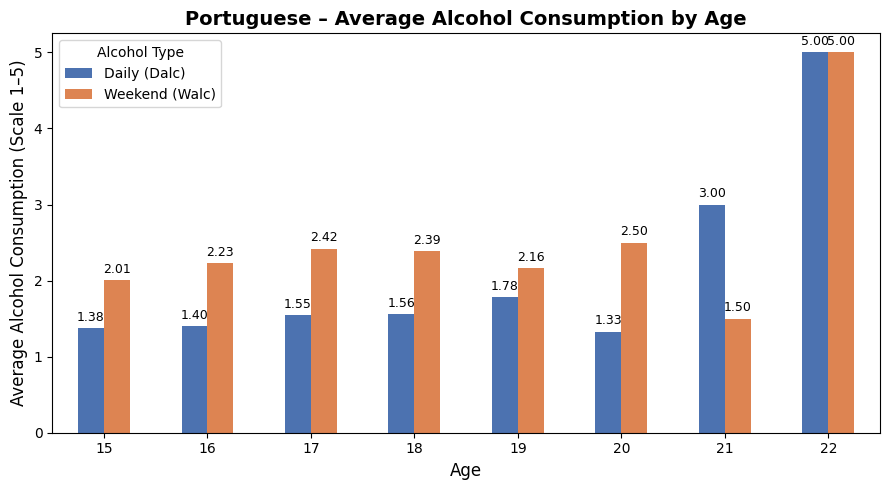

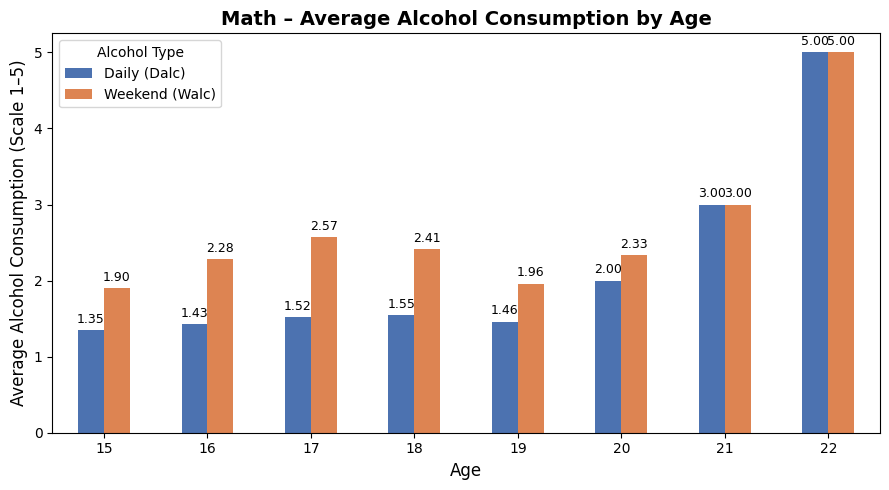

In [87]:
def plot_age_alcohol(data, title, colors):
    ax = data.plot(kind='bar', figsize=(9,5), color=colors)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    plt.title(title, fontsize=14, weight='bold')
    plt.ylabel("Average Alcohol Consumption (Scale 1–5)", fontsize=12)
    plt.xlabel("Age", fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(["Daily (Dalc)", "Weekend (Walc)"], title="Alcohol Type")
    plt.tight_layout()
    plt.show()

# Plot both datasets
plot_age_alcohol(age_alc_pre, "Portuguese – Average Alcohol Consumption by Age",
                 ["#4C72B0", "#DD8452"])

plot_age_alcohol(age_alc_mat, "Math – Average Alcohol Consumption by Age",
                 ["#4C72B0", "#DD8452"])

In [86]:
age_g3_alc_pre = df_pre.groupby('age')[['G3','Dalc','Walc']].mean().round(2)
age_g3_alc_mat = df_mat.groupby('age')[['G3','Dalc','Walc']].mean().round(2)

print("Portuguese – Age, Alcohol & G3:\n", age_g3_alc_pre, "\n")
print("Math – Age, Alcohol & G3:\n", age_g3_alc_mat, "\n")


Portuguese – Age, Alcohol & G3:
         G3  Dalc  Walc
age                   
15   12.11  1.38  2.01
16   11.99  1.40  2.23
17   12.27  1.55  2.42
18   11.77  1.56  2.39
19    9.53  1.78  2.16
20   12.00  1.33  2.50
21   11.00  3.00  1.50
22    5.00  5.00  5.00 

Math – Age, Alcohol & G3:
         G3  Dalc  Walc
age                   
15   11.26  1.35  1.90
16   11.03  1.43  2.28
17   10.28  1.52  2.57
18    9.55  1.55  2.41
19    8.21  1.46  1.96
20   14.00  2.00  2.33
21    7.00  3.00  3.00
22    8.00  5.00  5.00 

